In [5]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from kmodes.kmodes import KModes

from retail_data import generate_retail_dataset

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42
     

In [ ]:
# 1. Load Retail Dataset
df = generate_retail_dataset(n_samples=2000, random_state=RANDOM_STATE)
print(f'Shape: {df.shape}')
df.head()

Shape: (2000, 11)


,CustomerID,Age,Annual_Income,Spending_Score,Region,Product_Category,Purchase_Channel,Num_Purchases,Avg_Transaction_Value,Total_Sales,Customer_Segment
0,1,22,107813,32,East,Furniture,In-Store,13,489.18,6663.34,Premium
1,2,58,26206,84,West,Clothing,Online,19,45.83,996.14,Regular
2,3,52,59752,4,East,Sports,In-Store,16,83.28,1471.70,Budget
3,4,40,65826,45,East,Electronics,Online,20,417.10,9209.14,Regular
4,5,40,99787,80,South,Groceries,Online,18,81.11,1467.51,VIP


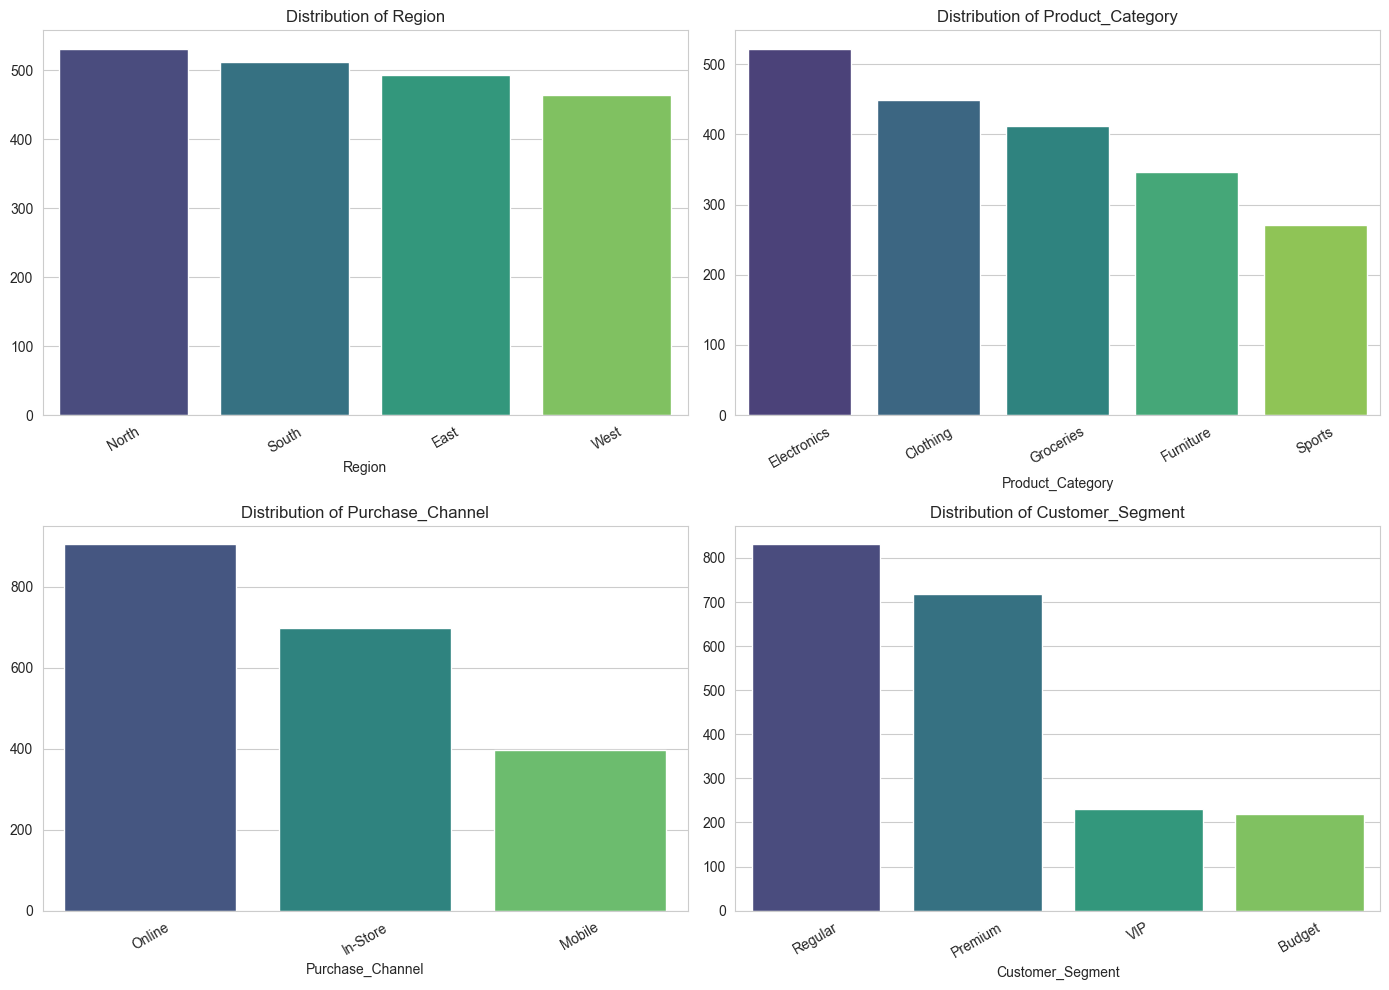

In [ ]:
# 2. Exploratory Data Analysis (Categorical Features)
cat_cols = ['Region', 'Product_Category', 'Purchase_Channel', 'Customer_Segment']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.ravel(), cat_cols):
    counts = df[col].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='viridis')
    ax.set_title(f'Distribution of {col}')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

     

In [9]:
print('Unique values per categorical column:')
for col in cat_cols:
    print(f'  {col}: {df[col].nunique()} -> {df[col].unique().tolist()}')


Unique values per categorical column:
  Region: 4 -> ['East', 'West', 'South', 'North']
  Product_Category: 5 -> ['Furniture', 'Clothing', 'Sports', 'Electronics', 'Groceries']
  Purchase_Channel: 3 -> ['In-Store', 'Online', 'Mobile']
  Customer_Segment: 4 -> ['Premium', 'Regular', 'Budget', 'VIP']


In [ ]:
# 3. Prepare Categorical Features for K-Modes
feature_cols = ['Region', 'Product_Category', 'Purchase_Channel']
X_cat = df[feature_cols].astype(str).values
print(f'Categorical feature matrix shape: {X_cat.shape}')
X_cat[:5]

Categorical feature matrix shape: (2000, 3)


array([['East', 'Furniture', 'In-Store'],
       ['West', 'Clothing', 'Online'],
       ['East', 'Sports', 'In-Store'],
       ['East', 'Electronics', 'Online'],
       ['South', 'Groceries', 'Online']], dtype=object)

K=2, Cost=3183.00
K=3, Cost=2841.00
K=4, Cost=2532.00
K=5, Cost=2274.00
K=6, Cost=2186.00
K=7, Cost=1896.00
K=8, Cost=1942.00


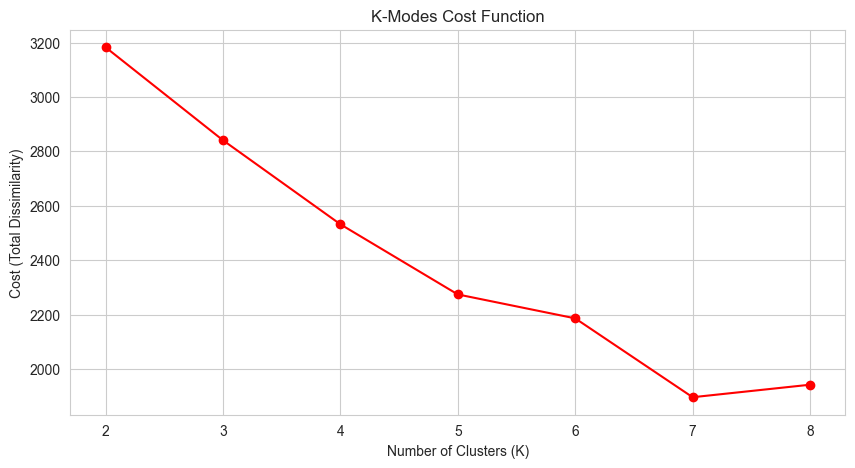

In [ ]:
# 4. Find Optimal K (Cost Function)
k_range = range(2, 9)
costs = []

for k in k_range:
    km = KModes(n_clusters=k, init='Huang', n_init=5, random_state=RANDOM_STATE)
    km.fit(X_cat)
    costs.append(km.cost_)
    print(f'K={k}, Cost={km.cost_:.2f}')

plt.figure(figsize=(10, 5))
plt.plot(k_range, costs, 'ro-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Cost (Total Dissimilarity)')
plt.title('K-Modes Cost Function')
plt.show()

In [14]:

# 5. Train Final K-Modes Model
OPTIMAL_K = 4
kmodes = KModes(n_clusters=OPTIMAL_K, init='Huang', n_init=10, random_state=RANDOM_STATE)
df['Cluster'] = kmodes.fit_predict(X_cat)

print('Cluster distribution:')
print(df['Cluster'].value_counts().sort_index())
print(f'\nFinal Cost: {kmodes.cost_:.2f}')
print(f'\nCluster Centroids (modes):')
centroids_df = pd.DataFrame(kmodes.cluster_centroids_, columns=feature_cols)
centroids_df.index.name = 'Cluster'
centroids_df

Cluster distribution:
Cluster
0    918
1    468
2    345
3    269
Name: count, dtype: int64

Final Cost: 2479.00

Cluster Centroids (modes):


,Region,Product_Category,Purchase_Channel
Cluster,,,
0,East,Electronics,Online
1,North,Furniture,In-Store
2,West,Groceries,Online
3,South,Sports,In-Store


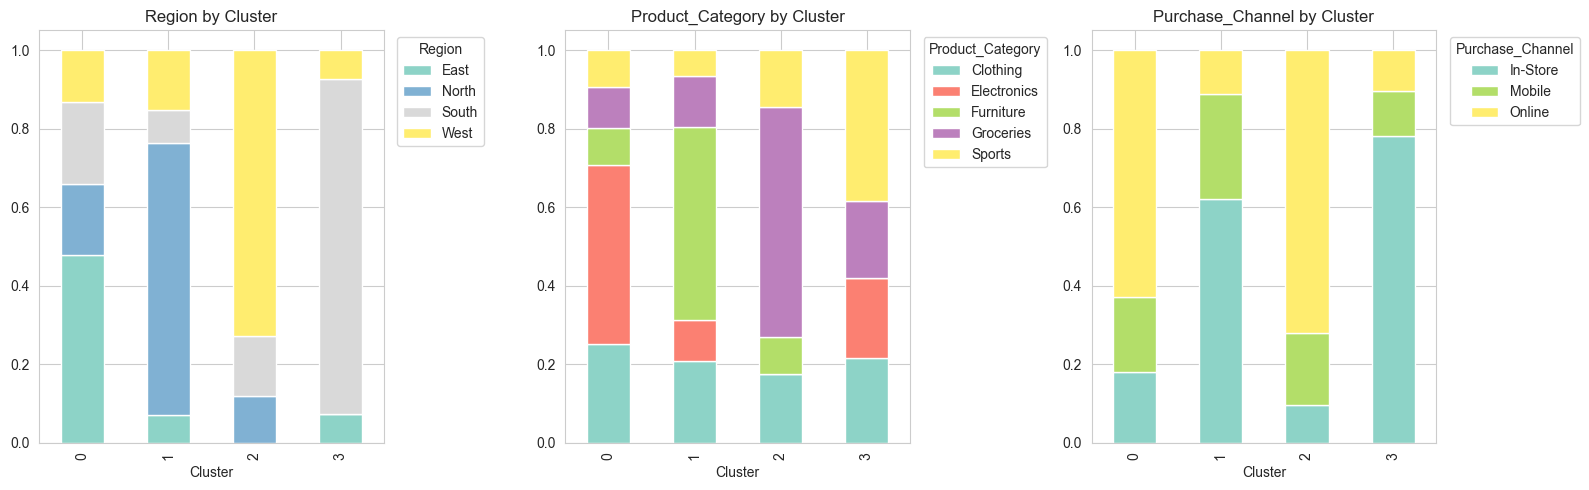

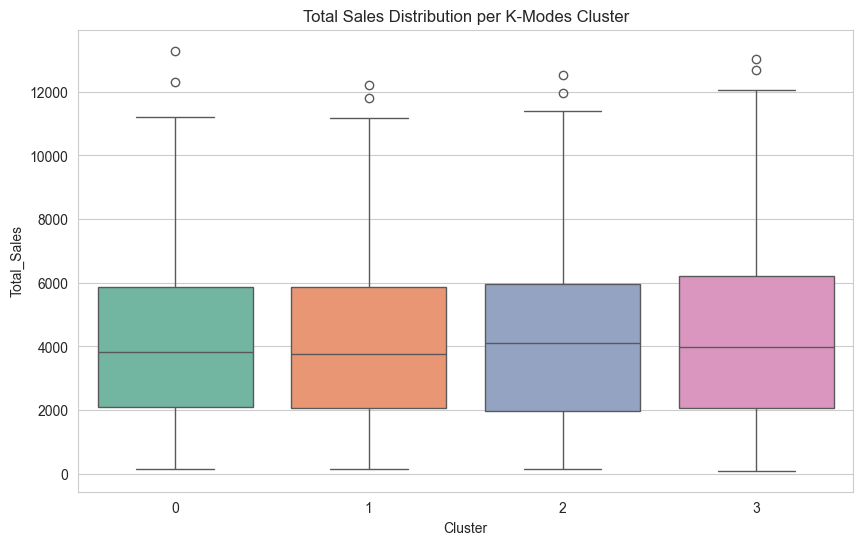

In [18]:
# Visualize Cluster Composition
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, feature_cols):
    ct = pd.crosstab(df['Cluster'], df[col], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=ax, colormap='Set3')
    ax.set_title(f'{col} by Cluster')
    ax.set_xlabel('Cluster')
    ax.legend(title=col, bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()
     

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Cluster', y='Total_Sales', palette='Set2')
plt.title('Total Sales Distribution per K-Modes Cluster')
plt.show()

In [20]:

# 7. Cluster Profiling
for cluster_id in sorted(df['Cluster'].unique()):
    subset = df[df['Cluster'] == cluster_id]
    print(f'\n--- Cluster {cluster_id} (n={len(subset)}) ---')
    for col in feature_cols:
        top = subset[col].mode()[0]
        pct = (subset[col] == top).mean() * 100
        print(f'  {col}: {top} ({pct:.1f}%)')
    print(f'  Avg Total Sales: ${subset["Total_Sales"].mean():,.2f}')
    print(f'  Avg Annual Income: ${subset["Annual_Income"].mean():,.0f}')
     

pd.crosstab(df['Cluster'], df['Customer_Segment'], normalize='index').round(2)


--- Cluster 0 (n=918) ---
  Region: East (47.9%)
  Product_Category: Electronics (45.5%)
  Purchase_Channel: Online (62.9%)
  Avg Total Sales: $4,088.61
  Avg Annual Income: $71,790

--- Cluster 1 (n=468) ---
  Region: North (69.2%)
  Product_Category: Furniture (48.9%)
  Purchase_Channel: In-Store (62.0%)
  Avg Total Sales: $4,075.11
  Avg Annual Income: $70,044

--- Cluster 2 (n=345) ---
  Region: West (72.8%)
  Product_Category: Groceries (58.6%)
  Purchase_Channel: Online (71.9%)
  Avg Total Sales: $4,259.23
  Avg Annual Income: $67,621

--- Cluster 3 (n=269) ---
  Region: South (85.1%)
  Product_Category: Sports (38.3%)
  Purchase_Channel: In-Store (78.1%)
  Avg Total Sales: $4,301.49
  Avg Annual Income: $68,612


Customer_Segment,Budget,Premium,Regular,VIP
Cluster,,,,
0,0.10,0.36,0.41,0.13
1,0.11,0.36,0.42,0.11
2,0.13,0.38,0.42,0.07
3,0.12,0.33,0.43,0.13
